In [1]:
!pip install pulp

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pulp import LpMaximize, LpProblem, LpVariable, LpStatus

   ---------------------------------------- 0.0/16.4 MB ? eta -:--:--
   ----- ---------------------------------- 2.4/16.4 MB 20.7 MB/s eta 0:00:01
   ------------------ --------------------- 7.6/16.4 MB 22.7 MB/s eta 0:00:01
   ------------------------- -------------- 10.5/16.4 MB 19.2 MB/s eta 0:00:01
   ------------------------------------ --- 14.9/16.4 MB 20.0 MB/s eta 0:00:01
   ---------------------------------------  16.3/16.4 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 16.4/16.4 MB 16.3 MB/s  0:00:01


In [4]:
#Load Dataset
df=pd.read_csv(r"C:\Users\lithe\Downloads\archive (6)\Sample - Superstore.csv",encoding='latin1')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
# Select required columns and data preprocessing
df = df[['Category', 'Sales', 'Profit']]

# Group by Category
df_grouped = df.groupby('Category').sum().reset_index()

df_grouped

,Category,Sales,Profit
0,Furniture,741999.7953,18451.2728
1,Office Supplies,719047.0320,122490.8008
2,Technology,836154.0330,145454.9481


In [12]:
# Create LP model/Optimization model
model = LpProblem("Retail_Profit_Maximization", LpMaximize)

In [13]:
# Create list of categories
categories = df_grouped['Category'].tolist()

# Decision variables (how much to invest per category)
x = LpVariable.dicts("Units", categories, lowBound=0)

In [14]:
# Create profit dictionary
profit_dict = dict(zip(df_grouped['Category'], df_grouped['Profit']))

# Add objective function
model += sum(profit_dict[i] * x[i] for i in categories)

In [15]:
# Create sales dictionary (acts like cost)
sales_dict = dict(zip(df_grouped['Category'], df_grouped['Sales']))

# Budget constraint
budget = 500000  # you can adjust this

model += sum(sales_dict[i] * x[i] for i in categories) <= budget

In [16]:
#Solve and check status of model

model.solve()


print("Status:", LpStatus[model.status])

Status: Optimal


In [17]:
print("\nOptimal Investment Plan:\n")

for i in categories:
    print(f"{i}: {x[i].value()}")

print("\nMaximum Profit:", model.objective.value())


Optimal Investment Plan:

Furniture: 0.0
Office Supplies: 0.0
Technology: 0.59797595

Maximum Profit: 86978.56077229821


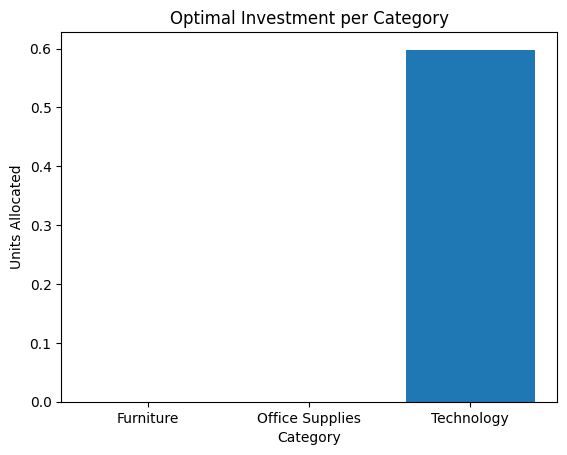

In [18]:
#Visualize using plots
# Plot results
values = [x[i].value() for i in categories]

plt.figure()
plt.bar(categories, values)
plt.title("Optimal Investment per Category")
plt.xlabel("Category")
plt.ylabel("Units Allocated")
plt.show()

In [21]:
#Constraint analysis
for name, constraint in model.constraints.items():
    print(f"{name}: {constraint.value()}")

_C1: 0.0022295063827186823


In [26]:
#This shows that the limitation in profit is due to restricted budget, not poor allocation.

In [28]:
#Resource Utilisation Analysis
total_used = sum(sales_dict[i] * x[i].value() for i in categories)
print("Total Budget Used:", total_used)

Total Budget Used: 500000.0022295064


In [34]:
### Resource Utilization:

 #The model utilizes nearly all available budget, ensuring no resource is wasted.
 #Efficient utilization indicates that the optimization model is functioning effectively

In [35]:
#Example analysis
budgets = [300000, 500000, 700000]
profits = []

for b in budgets:
    model = LpProblem("Test", LpMaximize)
    x = LpVariable.dicts("Units", categories, lowBound=0)

    model += sum(profit_dict[i] * x[i] for i in categories)
    model += sum(sales_dict[i] * x[i] for i in categories) <= b

    model.solve()
    profits.append(model.objective.value())

print(profits)

[52187.13646337892, 86978.56077229821, 121769.98508121747]


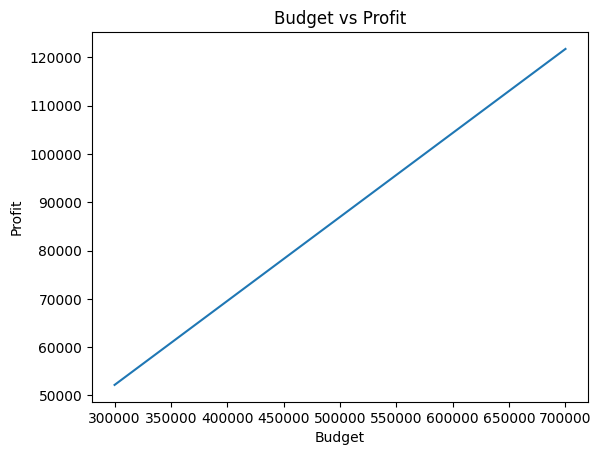

In [36]:
plt.plot(budgets, profits)
plt.xlabel("Budget")
plt.ylabel("Profit")
plt.title("Budget vs Profit")
plt.show()

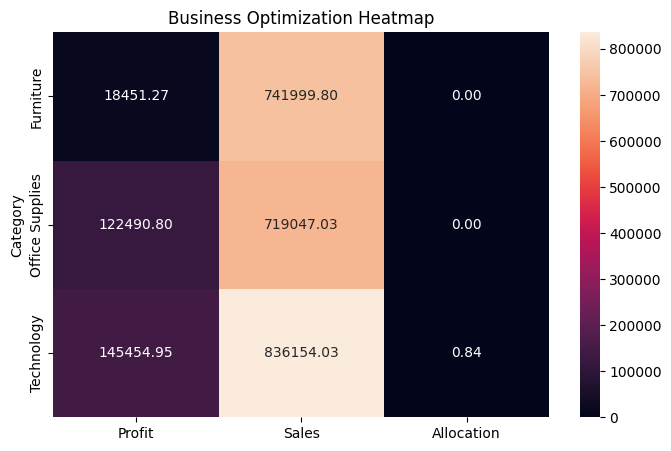

In [39]:
import seaborn as sns

# Create a new dataframe for visualization
heatmap_df = pd.DataFrame({
    'Category': categories,
    'Profit': [profit_dict[i] for i in categories],
    'Sales': [sales_dict[i] for i in categories],
    'Allocation': [x[i].value() for i in categories]
})

heatmap_df.set_index('Category', inplace=True)

heatmap_df
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_df, annot=True, fmt=".2f")

plt.title("Business Optimization Heatmap")
plt.show()

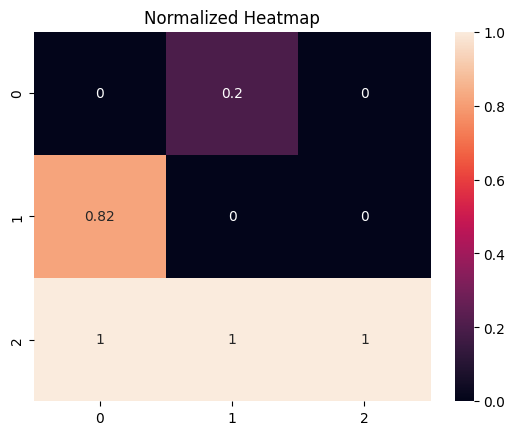

In [40]:
#Normalised..
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(heatmap_df)

sns.heatmap(scaled_data, annot=True)
plt.title("Normalized Heatmap")
plt.show()